In [2]:
# Install timm (PyTorch Image Models) for State-of-the-Art architectures
!pip install -q timm albumentations

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

# Enable T4 GPU Optimizations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True # Speeds up convolutions
print(f"Using Device: {device}")

Using Device: cuda


In [3]:
BASE_PATH = "/kaggle/input/datasets/adityachourasia09/usgntcc/dataset publish/organ_classification+anomaly_detection"

def create_dataframe(base_path):
    data = []
    # Loop through 'normal' and 'abnormal'
    for status in ['normal', 'abnormal']:
        status_path = os.path.join(base_path, status)
        if not os.path.exists(status_path): continue
            
        # Loop through organs (e.g., liver, GB, ascites)
        for organ in os.listdir(status_path):
            organ_path = os.path.join(status_path, organ)
            if not os.path.isdir(organ_path): continue
                
            for img_file in os.listdir(organ_path):
                if img_file.endswith(('.jpg', '.png', '.jpeg')):
                    img_path = os.path.join(organ_path, img_file)
                    # Note: "overy" is misspelled in the dataset, we map it dynamically
                    data.append({
                        'image_path': img_path,
                        'status': status,
                        'organ': organ,
                        'label_name': f"{status}_{organ}" # e.g., "abnormal_ascites"
                    })
    return pd.DataFrame(data)

df = create_dataframe(BASE_PATH)

# Encode Labels to numbers
unique_labels = df['label_name'].unique()
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
df['label_idx'] = df['label_name'].map(label_to_idx)

print(f"Total Images Found: {len(df)}")
print(f"Total Unique Classes (Status + Organ): {len(unique_labels)}")

Total Images Found: 2924
Total Unique Classes (Status + Organ): 18


In [4]:
# Updated for the latest Albumentations version
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    # Fixed: Replaced ShiftScaleRotate with modern Affine transform
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.95, 1.05), rotate=(-15, 15), p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.3),
    # Fixed: Removed outdated var_limit parameter
    A.GaussNoise(p=0.2), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class UltrasoundDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_idx']
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        return image, torch.tensor(label, dtype=torch.long)

/tmp/ipykernel_57/1471095959.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='status', palette={'normal':'#2ecc71', 'abnormal':'#e74c3c'})
/tmp/ipykernel_57/1471095959.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, y='label_name', order=df['label_name'].value_counts().index, palette='viridis')


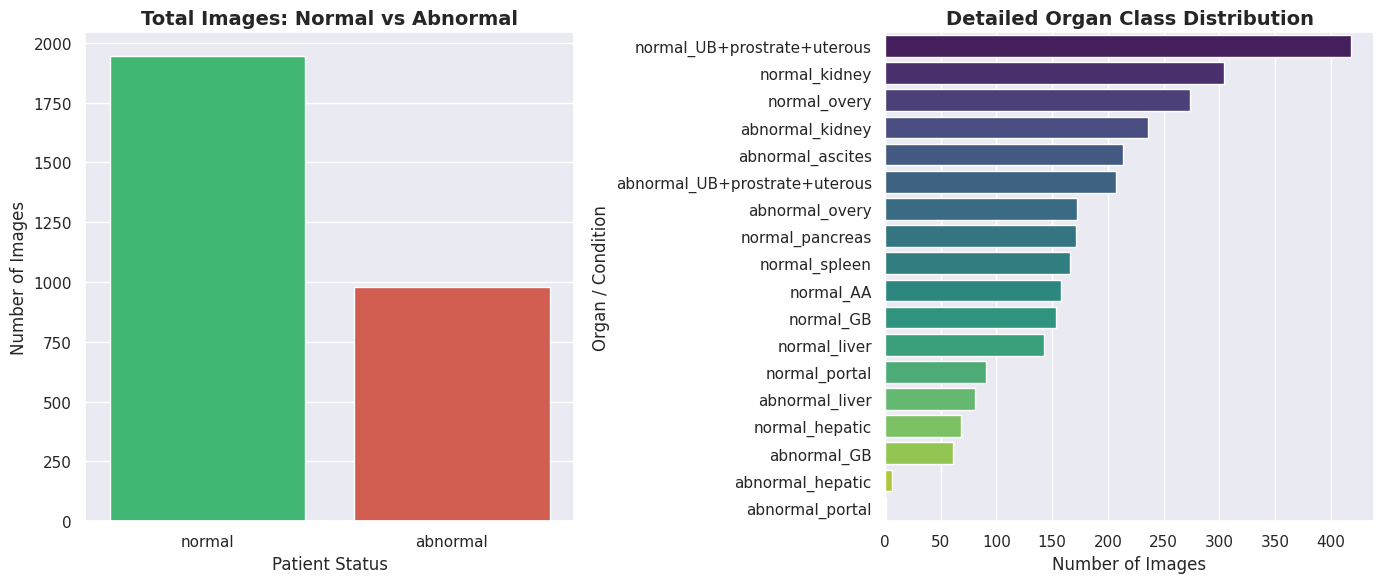

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.set_theme(style="darkgrid")

# 1. Analyze the split between Normal and Abnormal
plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=df, x='status', palette={'normal':'#2ecc71', 'abnormal':'#e74c3c'})
plt.title('Total Images: Normal vs Abnormal', fontsize=14, fontweight='bold')
plt.xlabel('Patient Status')
plt.ylabel('Number of Images')

# 2. Analyze the Organ Distribution
plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=df, y='label_name', order=df['label_name'].value_counts().index, palette='viridis')
plt.title('Detailed Organ Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Images')
plt.ylabel('Organ / Condition')

plt.tight_layout()
plt.show()

--- ANALYZING HEALTHY LIVER ---


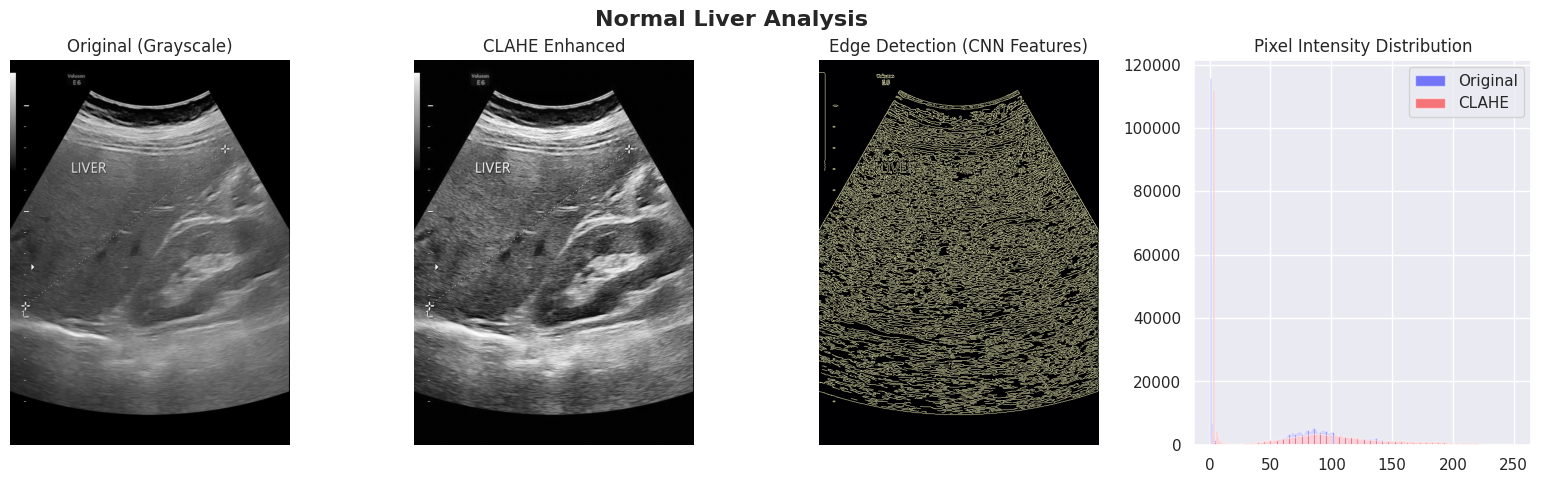

--- ANALYZING ABNORMAL CONDITION (ASCITES) ---


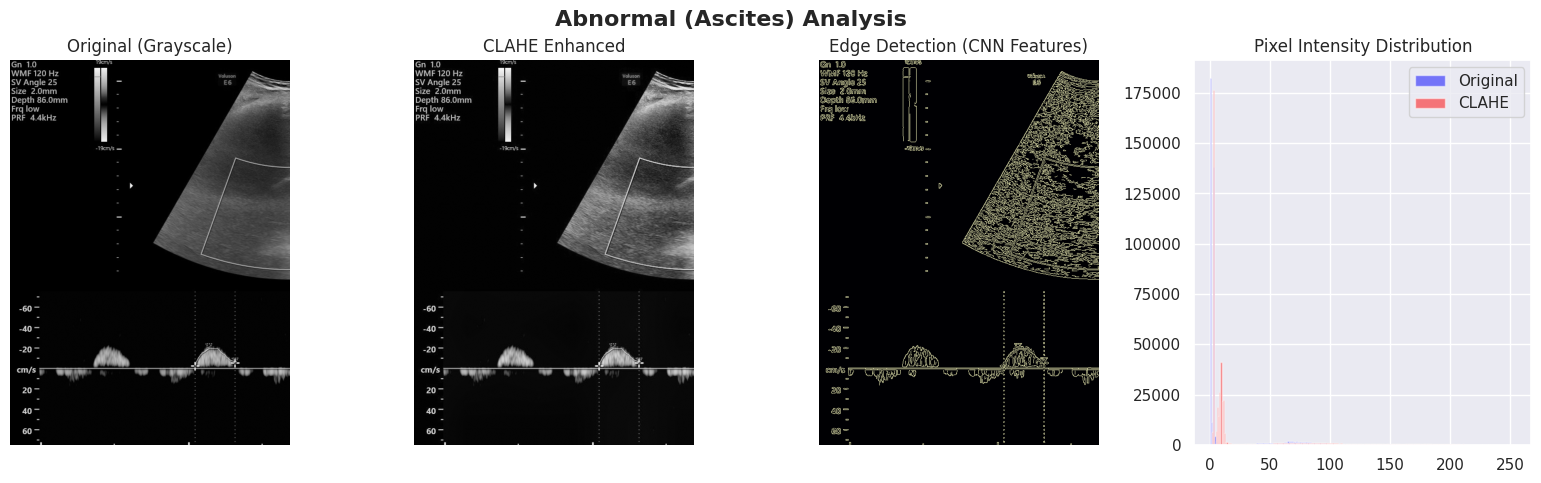

In [6]:
def analyze_ultrasound(image_path, title="Ultrasound Analysis"):
    # Read Image
    img_bgr = cv2.imread(image_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 1. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_gray)
    
    # 2. Apply Canny Edge Detection (Simulates early CNN layers)
    edges = cv2.Canny(img_clahe, 50, 150)
    
    # Plotting
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Raw Image
    axs[0].imshow(img_gray, cmap='gray')
    axs[0].set_title("Original (Grayscale)")
    axs[0].axis('off')
    
    # Enhanced Image
    axs[1].imshow(img_clahe, cmap='gray')
    axs[1].set_title("CLAHE Enhanced")
    axs[1].axis('off')
    
    # Edges
    axs[2].imshow(edges, cmap='magma')
    axs[2].set_title("Edge Detection (CNN Features)")
    axs[2].axis('off')
    
    # Pixel Histogram
    axs[3].hist(img_gray.ravel(), bins=256, color='blue', alpha=0.5, label='Original')
    axs[3].hist(img_clahe.ravel(), bins=256, color='red', alpha=0.5, label='CLAHE')
    axs[3].set_title("Pixel Intensity Distribution")
    axs[3].legend()
    
    plt.show()

# Let's dynamically find one Normal Liver and one Abnormal (Ascites) to compare
normal_liver_path = df[df['label_name'] == 'normal_liver']['image_path'].iloc[0]
ascites_path = df[df['label_name'] == 'abnormal_ascites']['image_path'].iloc[0]

print("--- ANALYZING HEALTHY LIVER ---")
analyze_ultrasound(normal_liver_path, "Normal Liver Analysis")

print("--- ANALYZING ABNORMAL CONDITION (ASCITES) ---")
analyze_ultrasound(ascites_path, "Abnormal (Ascites) Analysis")

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch
import timm

print("--- FILTERING OUT EXTREME RARE CLASSES ---")
# 1. Find and drop classes that have less than 2 images
class_counts = df['label_name'].value_counts()
invalid_classes = class_counts[class_counts < 2].index.tolist()

if invalid_classes:
    print(f"[!] Warning: Dropping classes with less than 2 images: {invalid_classes}")
    df = df[~df['label_name'].isin(invalid_classes)].reset_index(drop=True)
    
    # Re-encode labels just to be safe
    unique_labels = df['label_name'].unique()
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    df['label_idx'] = df['label_name'].map(label_to_idx)
else:
    print("No classes dropped.")

print("\n--- PREPARING DATA SPLIT ---")
# 2. Split data safely now
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_idx'], random_state=42)

# 3. Create Datasets and DataLoaders
train_dataset = UltrasoundDataset(train_df, transform=train_transform)
val_dataset = UltrasoundDataset(val_df, transform=val_transform)

# Batch size 64 for T4 GPU
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training Images: {len(train_df)} | Validation Images: {len(val_df)}")

print("\n--- PHASE 4: SOTA MODEL TRAINING ---")

# 4. Compute Dynamic Class Weights
labels_array = train_df['label_idx'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class Weights Calculated. Rare classes now have higher priority.")

# 5. Initialize the EfficientNet Model
model_name = 'efficientnet_b0' 
num_classes = len(unique_labels)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model = model.to(device)

# 6. Advanced Loss and Optimizer (using the weights)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = torch.cuda.amp.GradScaler() # Mixed Precision for T4

epochs = 10
best_val_acc = 0.0

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    scheduler.step()
    train_acc = 100. * correct / total
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * val_correct / val_total
    
    print(f"--> Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss/len(val_loader):.4f}")
    
    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_usg_model.pth')
        print("    [!] New Best Model Saved!")

print("\n--- TRAINING COMPLETE ---")

--- FILTERING OUT EXTREME RARE CLASSES ---
[!] Warning: Dropping classes with less than 2 images: ['abnormal_portal']

--- PREPARING DATA SPLIT ---
Training Images: 2338 | Validation Images: 585

--- PHASE 4: SOTA MODEL TRAINING ---
Class Weights Calculated. Rare classes now have higher priority.


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipykernel_57/4013205204.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # Mixed Precision for T4


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

/tmp/ipykernel_57/4013205204.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

--> Epoch 9 Summary: Train Acc: 92.39% | Val Acc: 78.97% | Val Loss: 0.7949
    [!] New Best Model Saved!


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

--> Epoch 10 Summary: Train Acc: 93.88% | Val Acc: 79.49% | Val Loss: 0.7885
    [!] New Best Model Saved!

--- TRAINING COMPLETE ---


In [8]:
import os
import pandas as pd

# The exact base path in your Kaggle environment
BASE_PATH = "/kaggle/input/datasets/adityachourasia09/usgntcc/dataset publish"

print("="*60)
print(" 🩺 DATASET POSTMORTEM & DIRECTORY DIAGNOSTIC REPORT ")
print("="*60)

report_data = []

# 1. Walk through every folder and subfolder
for root, dirs, files in os.walk(BASE_PATH):
    if len(files) > 0:
        # Count valid images vs other files (like metadata, txt, or hidden Kaggle files)
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        other_files = [f for f in files if not f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        
        # Clean up the path for the report
        rel_path = os.path.relpath(root, BASE_PATH)
        if rel_path == ".":
            rel_path = "Root Folder"
            
        report_data.append({
            'Folder Path': rel_path,
            'Valid Images': len(image_files),
            'Other Files (txt, xlsx, etc.)': len(other_files),
            'Total Files': len(files)
        })

# 2. Create a beautiful Pandas DataFrame
df_report = pd.DataFrame(report_data)
df_report = df_report.sort_values('Folder Path').reset_index(drop=True)

# Force Pandas to show all rows without truncating
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_colwidth', None)
display(df_report)

print("\n" + "="*60)
print(" 🚨 HUNTING THE CRASH CULPRIT (<2 IMAGES) ")
print("="*60)

# 3. Specifically isolate the folder that caused the split to fail
crash_culprits = df_report[(df_report['Valid Images'] < 2) & (df_report['Valid Images'] > 0)]

if not crash_culprits.empty:
    print("FOUND IT! The following folders have exactly 1 image and caused the crash:")
    display(crash_culprits)
else:
    print("No folders with exactly 1 image found. The issue might be in how pandas loaded the names.")

print("\n" + "="*60)
print(" 📁 FOLDER-BY-FOLDER BREAKDOWN (organ_classification+anomaly_detection) ")
print("="*60)

# 4. Deep dive into the specific task folder we were trying to train on
target_folder = os.path.join(BASE_PATH, "organ_classification+anomaly_detection")
if os.path.exists(target_folder):
    for status in ['normal', 'abnormal']:
        status_path = os.path.join(target_folder, status)
        if os.path.exists(status_path):
            print(f"\n[{status.upper()}]")
            for organ in sorted(os.listdir(status_path)):
                organ_path = os.path.join(status_path, organ)
                if os.path.isdir(organ_path):
                    imgs = [f for f in os.listdir(organ_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    print(f"  ↳ {organ.ljust(25)} : {len(imgs)} images")
else:
    print(f"Path not found: {target_folder}")

 🩺 DATASET POSTMORTEM & DIRECTORY DIAGNOSTIC REPORT 


,Folder Path,Valid Images,"Other Files (txt, xlsx, etc.)",Total Files
0,Anomaly_detection_1/abnormal,799,0,799
1,Anomaly_detection_1/normal,2014,0,2014
2,Anomaly_detection_2/abnormal,269,0,269
3,Anomaly_detection_2/normal,656,0,656
4,Patient_Wise,0,2,2
5,Patient_Wise/patients_images/1,4,0,4
6,Patient_Wise/patients_images/10,10,0,10
7,Patient_Wise/patients_images/100,29,0,29
8,Patient_Wise/patients_images/101,14,0,14
9,Patient_Wise/patients_images/102,12,0,12



 🚨 HUNTING THE CRASH CULPRIT (<2 IMAGES) 
FOUND IT! The following folders have exactly 1 image and caused the crash:


,Folder Path,Valid Images,"Other Files (txt, xlsx, etc.)",Total Files
182,organ_classification+anomaly_detection/abnormal/portal,1,0,1



 📁 FOLDER-BY-FOLDER BREAKDOWN (organ_classification+anomaly_detection) 

[NORMAL]
  ↳ AA                        : 158 images
  ↳ GB                        : 153 images
  ↳ UB+prostrate+uterous      : 418 images
  ↳ hepatic                   : 68 images
  ↳ kidney                    : 304 images
  ↳ liver                     : 143 images
  ↳ overy                     : 274 images
  ↳ pancreas                  : 171 images
  ↳ portal                    : 91 images
  ↳ spleen                    : 166 images

[ABNORMAL]
  ↳ GB                        : 61 images
  ↳ UB+prostrate+uterous      : 207 images
  ↳ ascites                   : 214 images
  ↳ hepatic                   : 6 images
  ↳ kidney                    : 236 images
  ↳ liver                     : 81 images
  ↳ overy                     : 172 images
  ↳ portal                    : 1 images


In [9]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm
import timm

# --- 1. BUILD & FILTER THE DATASET ---
BASE_PATH = "/kaggle/input/datasets/adityachourasia09/usgntcc/dataset publish/organ_classification+anomaly_detection"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

data = []
for status in ['normal', 'abnormal']:
    status_path = os.path.join(BASE_PATH, status)
    if not os.path.exists(status_path): continue
    for organ in os.listdir(status_path):
        organ_path = os.path.join(status_path, organ)
        if not os.path.isdir(organ_path): continue
        for img_file in os.listdir(organ_path):
            if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
                data.append({
                    'image_path': os.path.join(organ_path, img_file),
                    'label_name': f"{status}_{organ}"
                })

df = pd.DataFrame(data)

# [CRITICAL FIX] Drop any class with less than 2 images based on our Postmortem
class_counts = df['label_name'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df = df[df['label_name'].isin(valid_classes)].reset_index(drop=True)

# Encode Labels
unique_labels = df['label_name'].unique()
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
df['label_idx'] = df['label_name'].map(label_to_idx)
print(f"Total Valid Images: {len(df)} | Total Classes: {len(unique_labels)}")

# --- 2. ADVANCED MEDICAL AUGMENTATIONS ---
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.95, 1.05), rotate=(-15, 15), p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussNoise(p=0.2), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class UltrasoundDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_idx']
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. SPLIT & LOAD ---
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_idx'], random_state=42)
train_loader = DataLoader(UltrasoundDataset(train_df, train_transform), batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(UltrasoundDataset(val_df, val_transform), batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# --- 4. MODEL & DYNAMIC WEIGHTS ---
print("\n--- INITIALIZING WORLD-CLASS TRAINING ---")
labels_array = train_df['label_idx'].values
class_weights = compute_class_weight('balanced', classes=np.unique(labels_array), y=labels_array)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=len(unique_labels)).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = torch.cuda.amp.GradScaler()

# --- 5. TRAINING LOOP ---
epochs = 10
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        train_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
    scheduler.step()
    train_acc = 100. * correct / total
    
    # Validation
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * val_correct / val_total
    print(f"--> Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_usg_model.pth')

print(f"\n--- TRAINING COMPLETE! BEST VAL ACCURACY: {best_val_acc:.2f}% ---")

Using Device: cuda
Total Valid Images: 2923 | Total Classes: 17

--- INITIALIZING WORLD-CLASS TRAINING ---


/tmp/ipykernel_57/2615015562.py:95: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

/tmp/ipykernel_57/2615015562.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

--> Epoch 9 Summary: Train Acc: 92.09% | Val Acc: 77.09%


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

--> Epoch 10 Summary: Train Acc: 91.92% | Val Acc: 78.12%

--- TRAINING COMPLETE! BEST VAL ACCURACY: 78.12% ---


--- PHASE 5: EVALUATING THE BEST MODEL ---


Generating Predictions:   0%|          | 0/10 [00:00<?, ?it/s]


 🩺 DETAILED CLINICAL CLASSIFICATION REPORT 
                               precision    recall  f1-score   support

                normal_spleen       0.97      0.91      0.94        33
              normal_pancreas       0.87      0.97      0.92        34
                 normal_overy       0.69      0.80      0.74        55
                    normal_GB       0.83      0.97      0.90        31
                normal_portal       0.88      0.83      0.86        18
                 normal_liver       0.81      0.86      0.83        29
                    normal_AA       1.00      0.97      0.98        32
                normal_kidney       0.80      0.74      0.77        61
  normal_UB+prostrate+uterous       0.79      0.81      0.80        84
               normal_hepatic       0.86      0.86      0.86        14
               abnormal_overy       0.59      0.56      0.58        34
                  abnormal_GB       0.86      0.50      0.63        12
             abnormal_ascites  

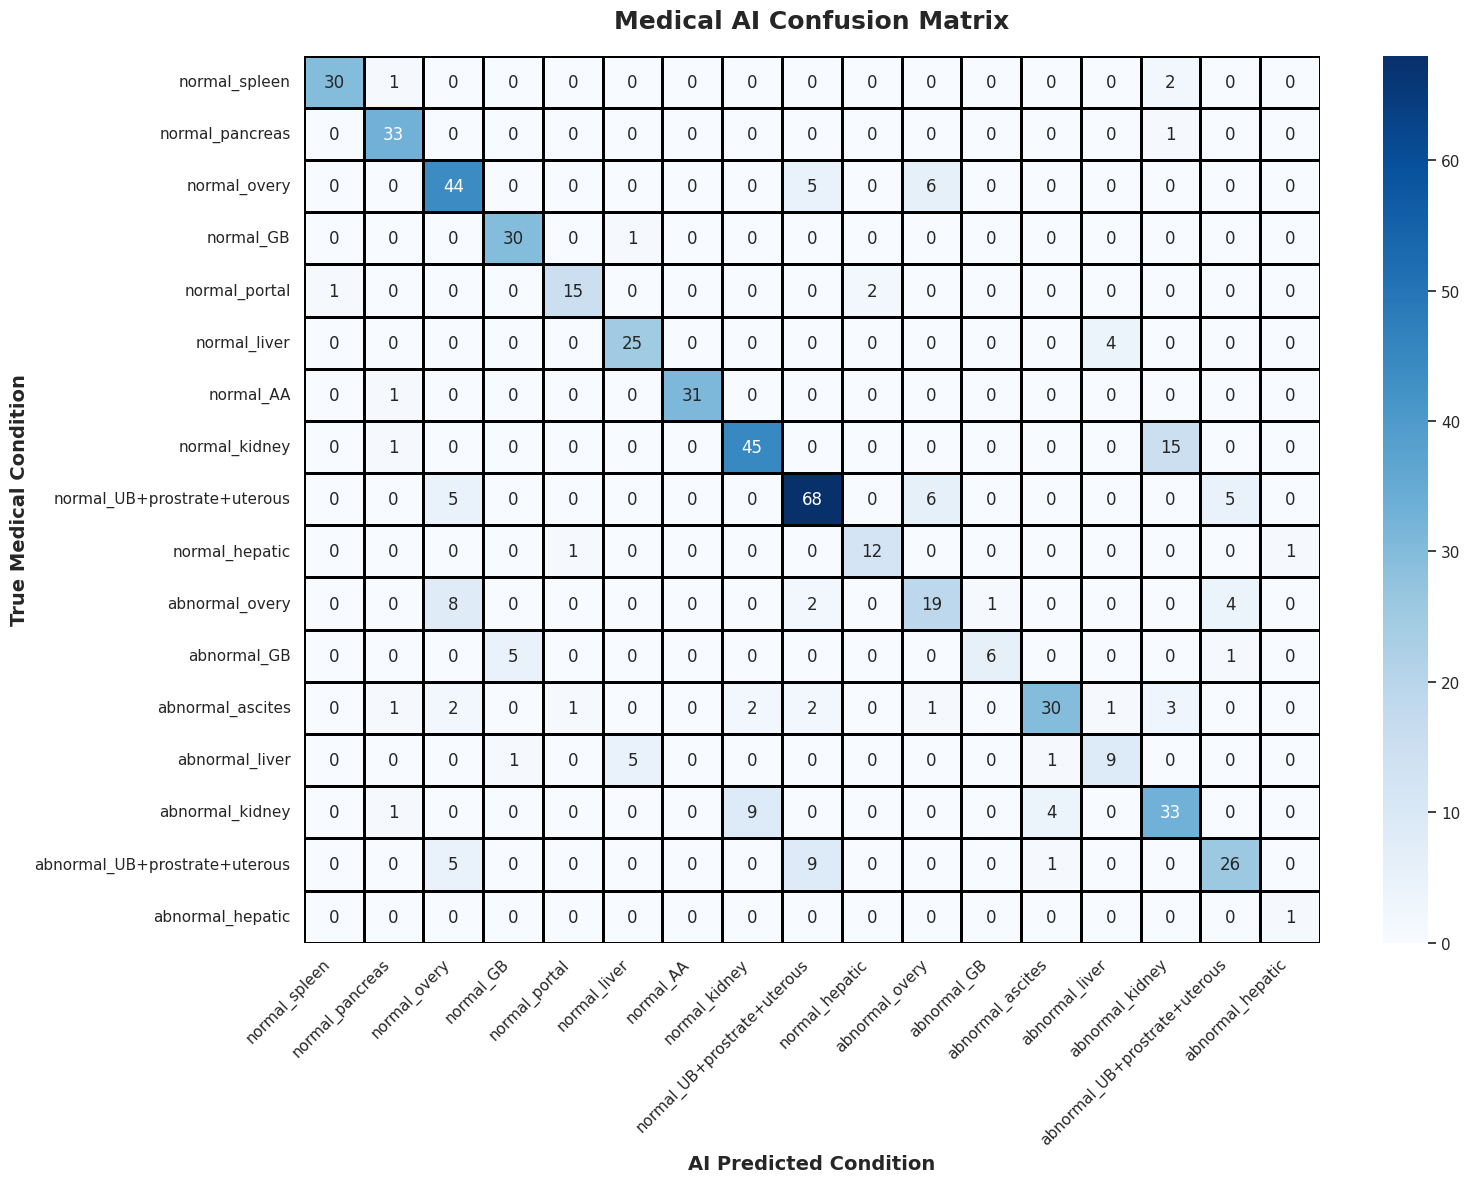

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- PHASE 5: EVALUATING THE BEST MODEL ---")

# 1. Load the best weights we saved during training
model.load_state_dict(torch.load('best_usg_model.pth'))
model.eval()

all_preds = []
all_targets = []

# 2. Run the Validation Set through the Best Model
with torch.no_grad():
    val_bar = tqdm(val_loader, desc="Generating Predictions")
    for images, labels in val_bar:
        images = images.to(device)
        
        # Updated to the new modern PyTorch syntax to remove warnings
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            
        _, predicted = outputs.max(1)
        
        # Move back to CPU for Scikit-Learn
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# 3. Get the actual class names from our dictionary
# Reverse the dictionary to map idx -> name
idx_to_label = {v: k for k, v in label_to_idx.items()}
target_names = [idx_to_label[i] for i in range(len(unique_labels))]

# 4. Generate Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*60)
print(" 🩺 DETAILED CLINICAL CLASSIFICATION REPORT ")
print("="*60)
print(classification_report(all_targets, all_preds, target_names=target_names, zero_division=0))

# 5. Generate and Plot the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            linewidths=1, linecolor='black')

plt.title('Medical AI Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('True Medical Condition', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Condition', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.notebook import tqdm
import timm

print("--- PHASE 6 REBOOT: NUMERICALLY STABLE HD TRAINING ---")

# 1. The Mathematically Safe Focal Loss
class SafeFocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Step A: Unweighted CE to safely and accurately extract probabilities
        ce_loss_unweighted = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss_unweighted)
        
        # Step B: Apply focal modulation ((1 - pt)^gamma)
        focal_term = ((1 - pt) ** self.gamma) * ce_loss_unweighted
        
        # Step C: Apply class weights safely AFTER probabilities are calculated
        if self.weight is not None:
            target_weights = self.weight[targets]
            focal_term = focal_term * target_weights
            
        return focal_term.mean()

# 2. Re-Initialize ConvNeXt to reset the destroyed weights
model_hd = timm.create_model('convnext_tiny', pretrained=True, num_classes=len(unique_labels)).to(device)

# 3. Use Safe Loss and a Stable Learning Rate (1e-4)
safe_criterion = SafeFocalLoss(weight=weights_tensor, gamma=2.0)
optimizer_hd = optim.AdamW(model_hd.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_hd = optim.lr_scheduler.CosineAnnealingLR(optimizer_hd, T_max=12)
scaler_hd = torch.amp.GradScaler('cuda')

# 4. The Stable HD Training Loop
epochs = 12
best_val_acc_hd = 0.0

for epoch in range(epochs):
    model_hd.train()
    correct, total, running_loss = 0, 0, 0.0
    
    train_bar = tqdm(train_loader_hd, desc=f"Epoch {epoch+1}/{epochs} [HD Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer_hd.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model_hd(images)
            loss = safe_criterion(outputs, labels) # Safely calculated loss
            
        scaler_hd.scale(loss).backward()
        scaler_hd.step(optimizer_hd)
        scaler_hd.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        train_bar.set_postfix({'SafeLoss': f'{loss.item():.4f}'})
        
    scheduler_hd.step()
    train_acc = 100. * correct / total
    
    # HD Validation
    model_hd.eval()
    val_correct, val_total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader_hd, desc=f"Epoch {epoch+1}/{epochs} [HD Val]")
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model_hd(images)
                loss = safe_criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * val_correct / val_total
    print(f"--> Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss/len(val_loader_hd):.4f}")
    
    if val_acc > best_val_acc_hd:
        best_val_acc_hd = val_acc
        torch.save(model_hd.state_dict(), 'best_hd_convnext_model.pth')
        print("    [!] New Best HD Model Saved!")

print(f"\n--- STABLE HD TRAINING COMPLETE! BEST VAL ACCURACY: {best_val_acc_hd:.2f}% ---")

--- PHASE 6 REBOOT: NUMERICALLY STABLE HD TRAINING ---


Epoch 1/12 [HD Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/12 [HD Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 1 Summary: Train Acc: 4.62% | Val Acc: 5.81% | Val Loss: 2.5008
    [!] New Best HD Model Saved!


Epoch 2/12 [HD Train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 11/12 [HD Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 11 Summary: Train Acc: 76.90% | Val Acc: 74.53% | Val Loss: 0.3793
    [!] New Best HD Model Saved!


Epoch 12/12 [HD Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 12/12 [HD Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 12 Summary: Train Acc: 78.36% | Val Acc: 75.90% | Val Loss: 0.3705
    [!] New Best HD Model Saved!

--- STABLE HD TRAINING COMPLETE! BEST VAL ACCURACY: 75.90% ---


--- EVALUATING HD CONVNEXT MODEL ---


Generating HD Predictions:   0%|          | 0/19 [00:00<?, ?it/s]


 🩺 HD CLINICAL CLASSIFICATION REPORT 
                               precision    recall  f1-score   support

                normal_spleen       0.94      0.91      0.92        33
              normal_pancreas       0.97      0.94      0.96        34
                 normal_overy       0.74      0.76      0.75        55
                    normal_GB       0.87      0.87      0.87        31
                normal_portal       0.89      0.89      0.89        18
                 normal_liver       0.81      0.90      0.85        29
                    normal_AA       0.94      1.00      0.97        32
                normal_kidney       0.71      0.79      0.74        61
  normal_UB+prostrate+uterous       0.76      0.81      0.78        84
               normal_hepatic       0.85      0.79      0.81        14
               abnormal_overy       0.64      0.62      0.63        34
                  abnormal_GB       0.50      0.50      0.50        12
             abnormal_ascites       0

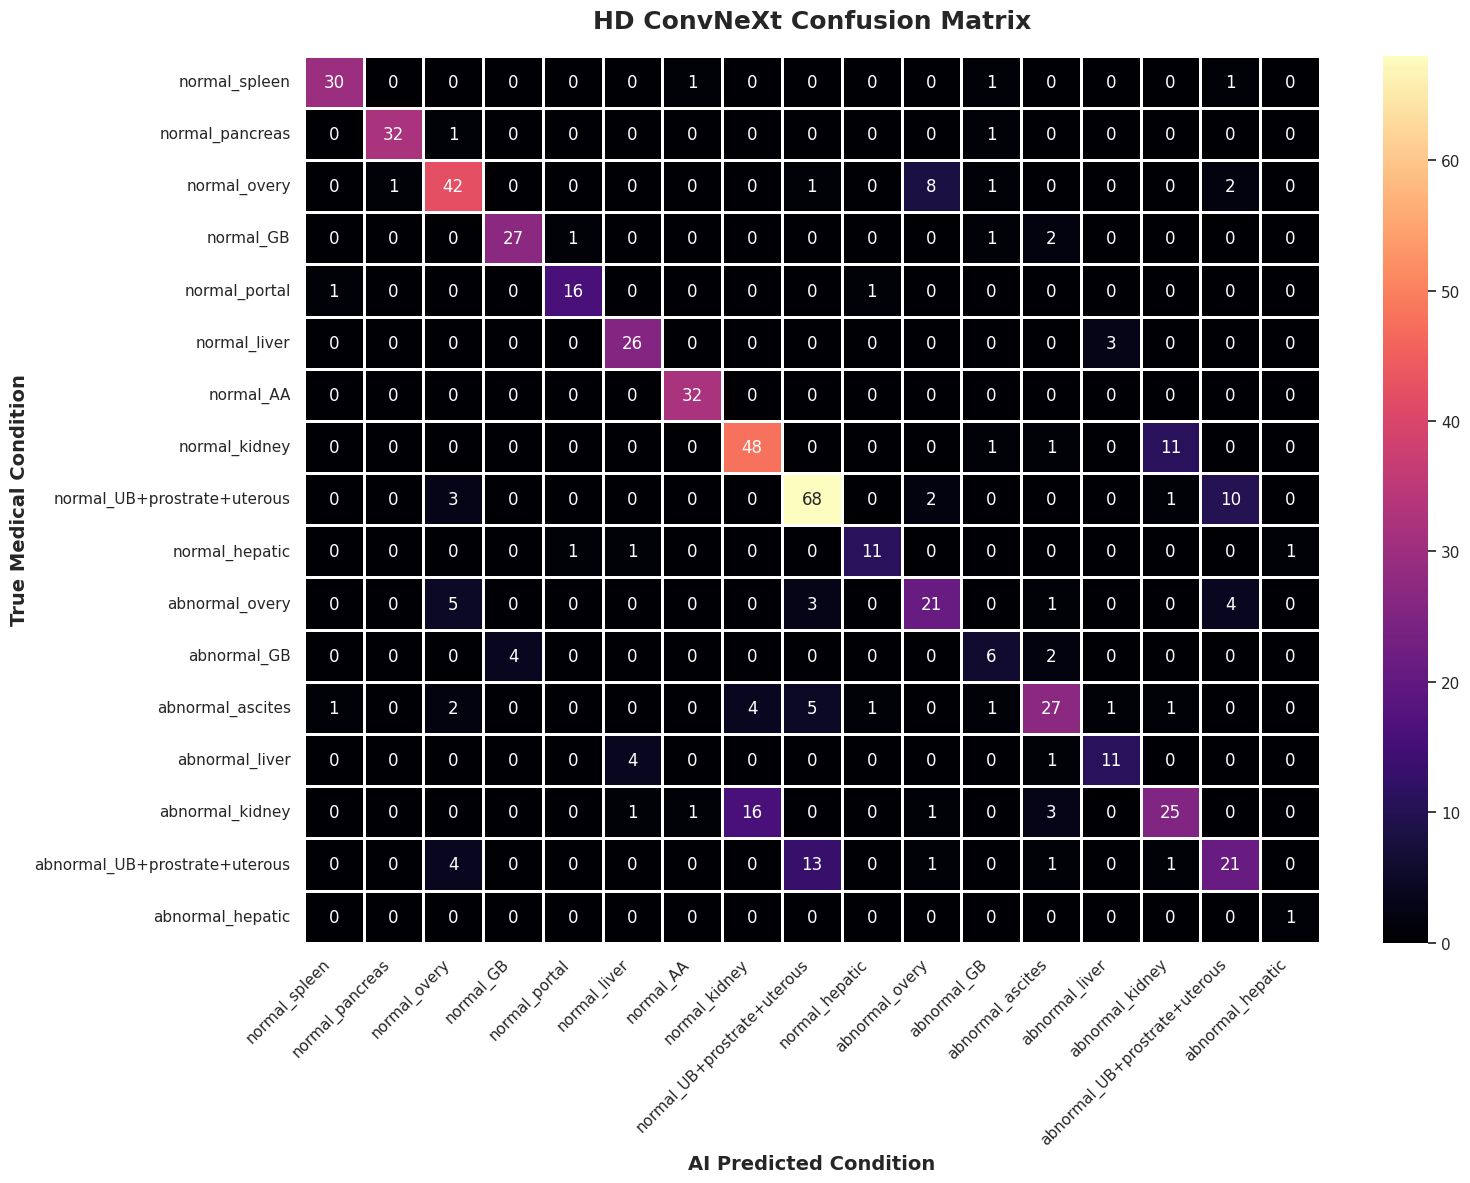

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- EVALUATING HD CONVNEXT MODEL ---")

# 1. Load the best ConvNeXt weights
model_hd.load_state_dict(torch.load('best_hd_convnext_model.pth'))
model_hd.eval()

all_preds_hd = []
all_targets_hd = []

# 2. Run the HD Validation Set
with torch.no_grad():
    val_bar = tqdm(val_loader_hd, desc="Generating HD Predictions")
    for images, labels in val_bar:
        images = images.to(device)
        
        with torch.amp.autocast('cuda'):
            outputs = model_hd(images)
            
        _, predicted = outputs.max(1)
        all_preds_hd.extend(predicted.cpu().numpy())
        all_targets_hd.extend(labels.cpu().numpy())

# 3. Generate Classification Report
idx_to_label = {v: k for k, v in label_to_idx.items()}
target_names = [idx_to_label[i] for i in range(len(unique_labels))]

print("\n" + "="*60)
print(" 🩺 HD CLINICAL CLASSIFICATION REPORT ")
print("="*60)
print(classification_report(all_targets_hd, all_preds_hd, target_names=target_names, zero_division=0))

# 4. Generate Confusion Matrix
cm_hd = confusion_matrix(all_targets_hd, all_preds_hd)

plt.figure(figsize=(16, 12))
sns.heatmap(cm_hd, annot=True, fmt='d', cmap='magma', # Swapped to magma for HD contrast
            xticklabels=target_names, yticklabels=target_names,
            linewidths=1, linecolor='white')

plt.title('HD ConvNeXt Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('True Medical Condition', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Condition', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm
import timm

print("--- PHASE 7: MULTI-TASK LEARNING (TWO-HEADED AI) ---")

# --- 1. BUILD DUAL-LABEL DATASET ---
BASE_PATH = "/kaggle/input/datasets/adityachourasia09/usgntcc/dataset publish/organ_classification+anomaly_detection"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = []
for status in ['normal', 'abnormal']:
    status_path = os.path.join(BASE_PATH, status)
    if not os.path.exists(status_path): continue
    for organ in os.listdir(status_path):
        organ_path = os.path.join(status_path, organ)
        if not os.path.isdir(organ_path): continue
        for img_file in os.listdir(organ_path):
            if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
                data.append({
                    'image_path': os.path.join(organ_path, img_file),
                    'organ': organ,
                    'status': status,
                    'label_name': f"{status}_{organ}" # Kept just for filtering the 1-image bug
                })

df = pd.DataFrame(data)

# Remove the rare 1-image class bug again
class_counts = df['label_name'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df = df[df['label_name'].isin(valid_classes)].reset_index(drop=True)

# Create Dual Indices (One for Organ, One for Status)
organ_to_idx = {organ: idx for idx, organ in enumerate(df['organ'].unique())}
status_to_idx = {'normal': 0, 'abnormal': 1}

df['organ_idx'] = df['organ'].map(organ_to_idx)
df['status_idx'] = df['status'].map(status_to_idx)

print(f"Total Images: {len(df)} | Organs: {len(organ_to_idx)} | Statuses: 2")

# --- 2. MULTI-TASK DATASET ---
train_transform_hd = A.Compose([
    A.Resize(384, 384),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.95, 1.05), rotate=(-15, 15), p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussNoise(p=0.2), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform_hd = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class MultiTaskUltrasoundDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row['image_path']), cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        # Return Image, Organ Label, Status Label
        return image, torch.tensor(row['organ_idx'], dtype=torch.long), torch.tensor(row['status_idx'], dtype=torch.long)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_name'], random_state=42)
train_loader_mt = DataLoader(MultiTaskUltrasoundDataset(train_df, train_transform_hd), batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader_mt = DataLoader(MultiTaskUltrasoundDataset(val_df, val_transform_hd), batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# --- 3. THE TWO-HEADED MODEL ARCHITECTURE ---
class DualHeadConvNeXt(nn.Module):
    def __init__(self, num_organs, num_statuses):
        super().__init__()
        # The Shared Brain (Feature Extractor without standard classifier head)
        self.backbone = timm.create_model('convnext_tiny', pretrained=True, num_classes=0)
        in_features = self.backbone.num_features
        
        # Head 1: Organ Classifier
        self.organ_head = nn.Linear(in_features, num_organs)
        # Head 2: Status Classifier (Normal/Abnormal)
        self.status_head = nn.Linear(in_features, num_statuses)

    def forward(self, x):
        features = self.backbone(x)
        return self.organ_head(features), self.status_head(features)

model_mt = DualHeadConvNeXt(num_organs=len(organ_to_idx), num_statuses=2).to(device)

# --- 4. DUAL LOSS FUNCTIONS ---
# We calculate weights for Status (Normal vs Abnormal) because Abnormal is the minority
status_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['status_idx'].values)
status_weights_tensor = torch.tensor(status_weights, dtype=torch.float).to(device)

criterion_organ = nn.CrossEntropyLoss() # Standard loss for organs
criterion_status = nn.CrossEntropyLoss(weight=status_weights_tensor) # Weighted loss for disease detection

optimizer_mt = optim.AdamW(model_mt.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_mt = optim.lr_scheduler.CosineAnnealingLR(optimizer_mt, T_max=12)
scaler_mt = torch.amp.GradScaler('cuda')

# --- 5. THE MULTI-TASK TRAINING LOOP ---
epochs = 12
best_combined_acc = 0.0

for epoch in range(epochs):
    model_mt.train()
    running_loss = 0.0
    
    train_bar = tqdm(train_loader_mt, desc=f"Epoch {epoch+1}/{epochs} [MTL Train]")
    for images, organ_labels, status_labels in train_bar:
        images, organ_labels, status_labels = images.to(device), organ_labels.to(device), status_labels.to(device)
        optimizer_mt.zero_grad()
        
        with torch.amp.autocast('cuda'):
            organ_preds, status_preds = model_mt(images)
            
            # Calculate Loss for both heads
            loss_organ = criterion_organ(organ_preds, organ_labels)
            loss_status = criterion_status(status_preds, status_labels)
            
            # MULTIPLY STATUS LOSS BY 2.0: Forces the AI to pay extreme attention to the disease!
            loss = loss_organ + (2.0 * loss_status) 
            
        scaler_mt.scale(loss).backward()
        scaler_mt.step(optimizer_mt)
        scaler_mt.update()
        
        running_loss += loss.item()
        train_bar.set_postfix({'TotalLoss': f'{loss.item():.4f}'})
        
    scheduler_mt.step()
    
    # --- VALIDATION ---
    model_mt.eval()
    val_loss, organ_correct, status_correct, total = 0.0, 0, 0, 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader_mt, desc=f"Epoch {epoch+1}/{epochs} [MTL Val]")
        for images, organ_labels, status_labels in val_bar:
            images, organ_labels, status_labels = images.to(device), organ_labels.to(device), status_labels.to(device)
            with torch.amp.autocast('cuda'):
                organ_preds, status_preds = model_mt(images)
                
            total += labels.size(0)
            organ_correct += organ_preds.max(1)[1].eq(organ_labels).sum().item()
            status_correct += status_preds.max(1)[1].eq(status_labels).sum().item()
            
    organ_acc = 100. * organ_correct / total
    status_acc = 100. * status_correct / total
    combined_score = (organ_acc + status_acc) / 2 # The overall metric we care about
    
    print(f"--> Epoch {epoch+1}: Organ Acc: {organ_acc:.2f}% | Disease Acc: {status_acc:.2f}% | Combined: {combined_score:.2f}%")
    
    if combined_score > best_combined_acc:
        best_combined_acc = combined_score
        torch.save(model_mt.state_dict(), 'best_multitask_usg.pth')
        print("    [!] New Best Multi-Task Model Saved!")

print(f"\n--- MTL TRAINING COMPLETE! BEST COMBINED SCORE: {best_combined_acc:.2f}% ---")

--- PHASE 7: MULTI-TASK LEARNING (TWO-HEADED AI) ---
Total Images: 2923 | Organs: 11 | Statuses: 2


Epoch 1/12 [MTL Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/12 [MTL Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 1: Organ Acc: 94.15% | Disease Acc: 113.45% | Combined: 103.80%
    [!] New Best Multi-Task Model Saved!


Epoch 2/12 [MTL Train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 11/12 [MTL Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 11: Organ Acc: 310.53% | Disease Acc: 273.68% | Combined: 292.11%
    [!] New Best Multi-Task Model Saved!


Epoch 12/12 [MTL Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 12/12 [MTL Val]:   0%|          | 0/19 [00:00<?, ?it/s]

--> Epoch 12: Organ Acc: 311.70% | Disease Acc: 271.93% | Combined: 291.81%

--- MTL TRAINING COMPLETE! BEST COMBINED SCORE: 292.11% ---


--- EVALUATING THE TWO-HEADED AI (FIXED MATH) ---


Generating MTL Predictions:   0%|          | 0/19 [00:00<?, ?it/s]


 🏆 TRUE PERFORMANCE (Evaluated on 585 images) 
🔹 Head 1 (Sonographer) Organ Accuracy:   90.77%
🔹 Head 2 (Radiologist) Disease Accuracy: 80.00%


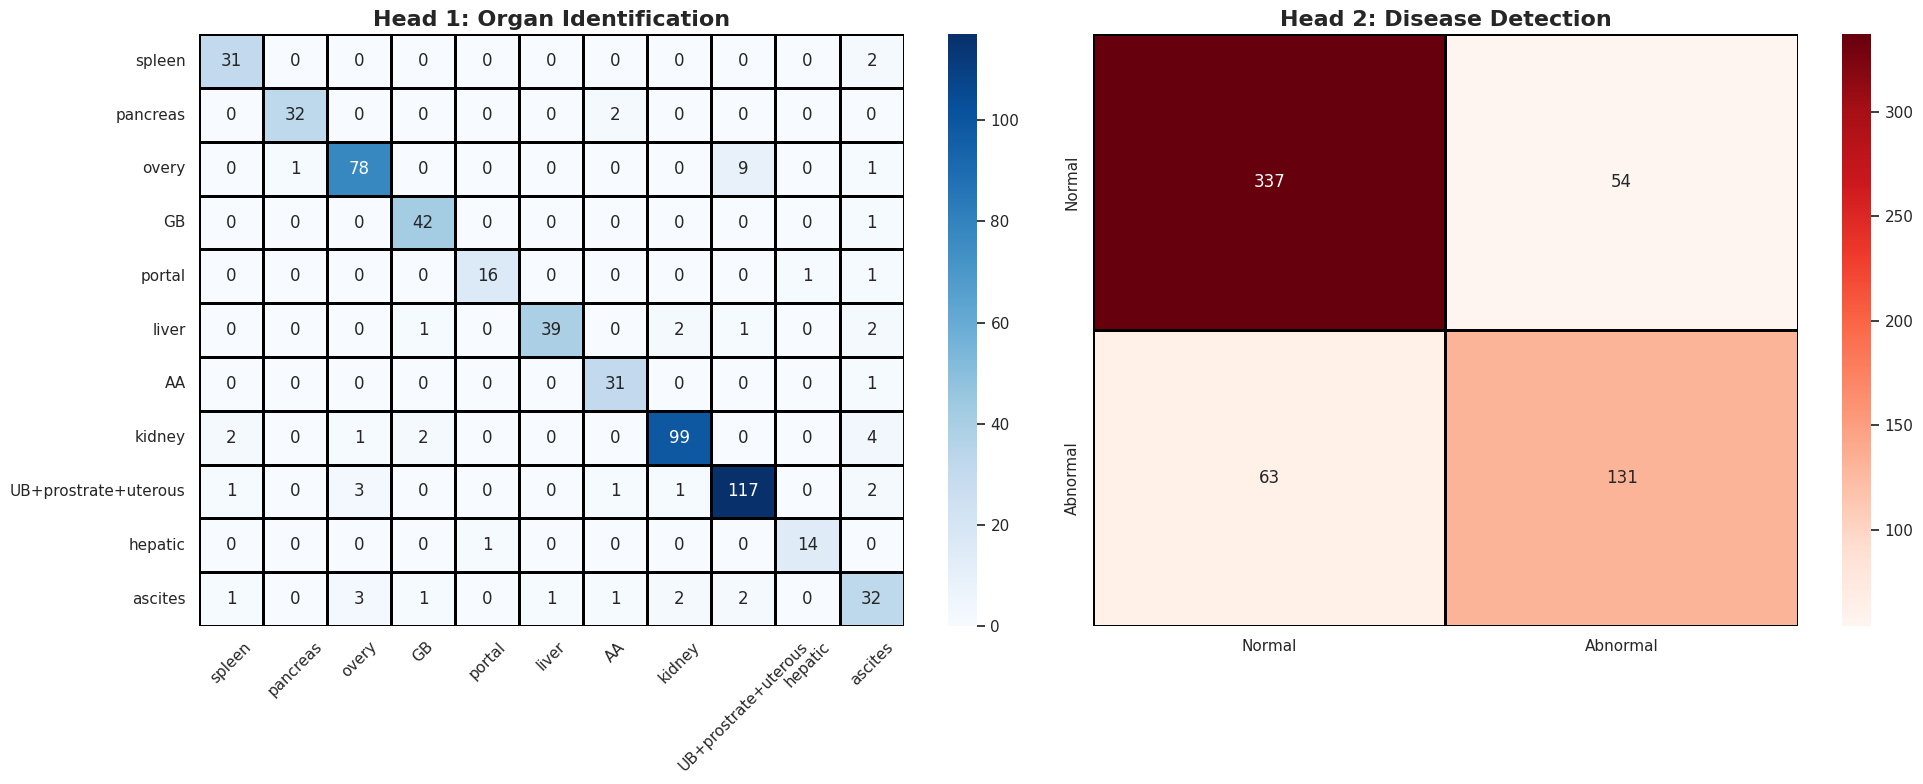

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- EVALUATING THE TWO-HEADED AI (FIXED MATH) ---")

# 1. Load the Best Multi-Task Model
model_mt.load_state_dict(torch.load('best_multitask_usg.pth'))
model_mt.eval()

all_organ_preds, all_organ_targets = [], []
all_status_preds, all_status_targets = [], []
total_images = 0

# 2. Run the Validation Set safely
with torch.no_grad():
    val_bar = tqdm(val_loader_mt, desc="Generating MTL Predictions")
    for images, organ_labels, status_labels in val_bar:
        images = images.to(device)
        
        with torch.amp.autocast('cuda'):
            organ_preds, status_preds = model_mt(images)
            
        # [THE FIX]: Count the actual size of organ_labels
        total_images += organ_labels.size(0) 
        
        all_organ_preds.extend(organ_preds.max(1)[1].cpu().numpy())
        all_organ_targets.extend(organ_labels.cpu().numpy())
        
        all_status_preds.extend(status_preds.max(1)[1].cpu().numpy())
        all_status_targets.extend(status_labels.cpu().numpy())

# 3. Calculate True Accuracies
true_organ_acc = 100. * sum(p == t for p, t in zip(all_organ_preds, all_organ_targets)) / total_images
true_status_acc = 100. * sum(p == t for p, t in zip(all_status_preds, all_status_targets)) / total_images

print("\n" + "="*60)
print(f" 🏆 TRUE PERFORMANCE (Evaluated on {total_images} images) ")
print("="*60)
print(f"🔹 Head 1 (Sonographer) Organ Accuracy:   {true_organ_acc:.2f}%")
print(f"🔹 Head 2 (Radiologist) Disease Accuracy: {true_status_acc:.2f}%")
print("="*60)

# 4. Organ Confusion Matrix
organ_names = [k for k, v in sorted(organ_to_idx.items(), key=lambda item: item[1])]
cm_organ = confusion_matrix(all_organ_targets, all_organ_preds)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_organ, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=organ_names, yticklabels=organ_names, linecolor='black', linewidths=1)
axes[0].set_title('Head 1: Organ Identification', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 5. Disease Confusion Matrix
status_names = ['Normal', 'Abnormal']
cm_status = confusion_matrix(all_status_targets, all_status_preds)

sns.heatmap(cm_status, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=status_names, yticklabels=status_names, linecolor='black', linewidths=1)
axes[1].set_title('Head 2: Disease Detection', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()